In [1]:
# =============================================================================
# ANALYSE EXPLORATOIRE DES DONNÉES (EDA) - DONNÉES RH
# =============================================================================
# 
# Objectif : Analyser les données employés avec focus sur les identifiants
#            hr_employee_hk et dim_lxp_user_hk
# 
# Auteur : Clement
# Date : 04-07-2025
# Version : 2.0
# 
# Table des matières :
# 1. Imports et configuration
# 2. Chargement et aperçu des données
# 3. Analyse de la qualité des données
# 4. Analyse des identifiants clés (hr_employee_hk, dim_lxp_user_hk)
# 5. Analyse univariée
# 6. Analyse bivariée
# 7. Analyse temporelle
# 8. Conclusions et recommandations
# =============================================================================


# Imports & Config

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuration des visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configuration pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


# Load Data - illustrative example

C'est toujours une bonne idée de jeter un oeil aux données avant de se lancer

In [ ]:
#df = pd.read_csv("../data/users_anonyme.csv", sep = '|')
df.head()

,Unnamed: 0,dim_lxp_user_hk,hr_employee_hk,user_windows,code_collaborateur,lastname,firstname,user_windowsn1,equipe,code_equipe,departement,function,code_function,function_group,debut_function,fin_function,nb_annees_dans_la_fonction,carto,rateworkingtime,startedon,finishedon,active_employee,employer_name,current_equipe,current_code_equipe,current_departement,current_function,current_code_function,current_function_group
0,0,e45ebc12002a18e957b333e3fd4405b680c1b652,c5f5af752e1b161729db95550bb54d145225517d,M527PDVI,10966,Giradello,Céline,M527DRIZ,PRC - Agence - Mons,524040,PRC,Conseiller Clientèle,F0031,Collaborateur,2017-12-01,2019-12-31,2.08,5.0,50.0,1983-11-07,2029-03-31,1,Partena-Mutualité Libre,PRC - Agence - Wallonie 4,523103,PRC,Conseiller Clientèle,F0031,Collaborateur
1,1,490603b4fc2fbeef71360c6eb7cb7acfa37f3972,a8433310b8017e6ab2f41d3ab8eba903178c7170,M527CDLV,11388,Sanjuan,Luana,M509WBEN,PRC - Assu - Equipe 3,412030,PRC,Responsable d'équipe,F0074,Responsable d'équipe,2017-12-01,NaN,7.59,6.0,100.0,1992-10-19,NaN,1,Partena-Mutualité Libre,PRC - Assu - Equipe 3,412030,PRC,Responsable d'équipe,F0074,Responsable d'équipe
2,2,c665deb95d087364ce34d1240209799b6341f296,130d31a3c6e2d77d9f5e809d4b7596f29a93a731,M527NDEL,11577,Pieper,Roland,M509SDAE,PRC - PM - Equipe 2,414020,PRC,Gestionnaire soins de santé,F0059,Collaborateur,2019-11-18,2022-11-30,3.03,3.0,100.0,1996-11-12,NaN,1,Partena-Mutualité Libre,PRC - PM - Equipe 2,414020,PRC,Gestionnaire soins de santé,F0059,Collaborateur
3,3,d2c918cd95010d66fc9ac0d5731b4a8dd6cc32b3,22cacf08e5669435f47bbd48ac1870bb0553ef08,M527NDEL,11577,Mude,Elmo,M509GBED,PRC - Assu - Equipe 2,412020,PRC,Gestionnaire assurabilité,F0049,Collaborateur,2018-02-19,2019-11-17,1.74,4.0,100.0,1996-11-12,NaN,1,Partena-Mutualité Libre,PRC - PM - Equipe 2,414020,PRC,Gestionnaire soins de santé,F0059,Collaborateur
4,4,706592958559c2b25ca865b6ab797e04cd56509c,b2eb291590995970b60d5dfe9e128ee31b6baf55,M509CDDY,11628,Maccanelli,Melissa,M509RBEM,PRC - Medical SDS - Equipe 2,414080,PRC,Gestionnaire médical soins de santé,F0058,Collaborateur,2022-03-28,2022-10-02,0.51,3.0,100.0,1997-10-07,NaN,1,Partena-Mutualité Libre,PRC - Medical SDS - Equipe 2,414080,PRC,Gestionnaire médical soins de santé,F0058,Collaborateur


On peut déjà droper les colonnes UnNamed. Il semblerait que quelqu'un ait mal fait l'import/export ..

In [14]:
df = df.drop(['Unnamed: 0'], axis = 1)

## Focus clefs dim


In [15]:
def analyze_key_identifiers(df):
    """
    Analyse approfondie des colonnes hr_employee_hk et dim_lxp_user_hk
    """
    print("🔍 ANALYSE DES IDENTIFIANTS CLÉS")
    print("=" * 50)
    
    # 1. Unicité des identifiants
    hr_unique = df['hr_employee_hk'].nunique()
    dim_unique = df['dim_lxp_user_hk'].nunique()
    total_rows = len(df)
    
    print(f"   • hr_employee_hk uniques : {hr_unique:,} / {total_rows:,} ({hr_unique/total_rows*100:.1f}%)")
    print(f"   • dim_lxp_user_hk uniques : {dim_unique:,} / {total_rows:,} ({dim_unique/total_rows*100:.1f}%)")
    
    # 2. Relation entre les deux identifiants
    mapping_analysis = df.groupby('hr_employee_hk')['dim_lxp_user_hk'].nunique()
    
    print(f"\n🔗 Relation hr_employee_hk ↔ dim_lxp_user_hk :")
    print(f"   • Employés avec 1 seul dim_lxp_user_hk : {(mapping_analysis == 1).sum():,}")
    print(f"   • Employés avec multiples dim_lxp_user_hk : {(mapping_analysis > 1).sum():,}")
    
    if (mapping_analysis > 1).any():
        max_mappings = mapping_analysis.max()
        print(f"   • Maximum de dim_lxp_user_hk par employé : {max_mappings}")
    
    return mapping_analysis

mapping_stats = analyze_key_identifiers(df)


🔍 ANALYSE DES IDENTIFIANTS CLÉS
   • hr_employee_hk uniques : 1,530 / 4,853 (31.5%)
   • dim_lxp_user_hk uniques : 4,766 / 4,853 (98.2%)

🔗 Relation hr_employee_hk ↔ dim_lxp_user_hk :
   • Employés avec 1 seul dim_lxp_user_hk : 431
   • Employés avec multiples dim_lxp_user_hk : 1,099
   • Maximum de dim_lxp_user_hk par employé : 18


## Visus clefs

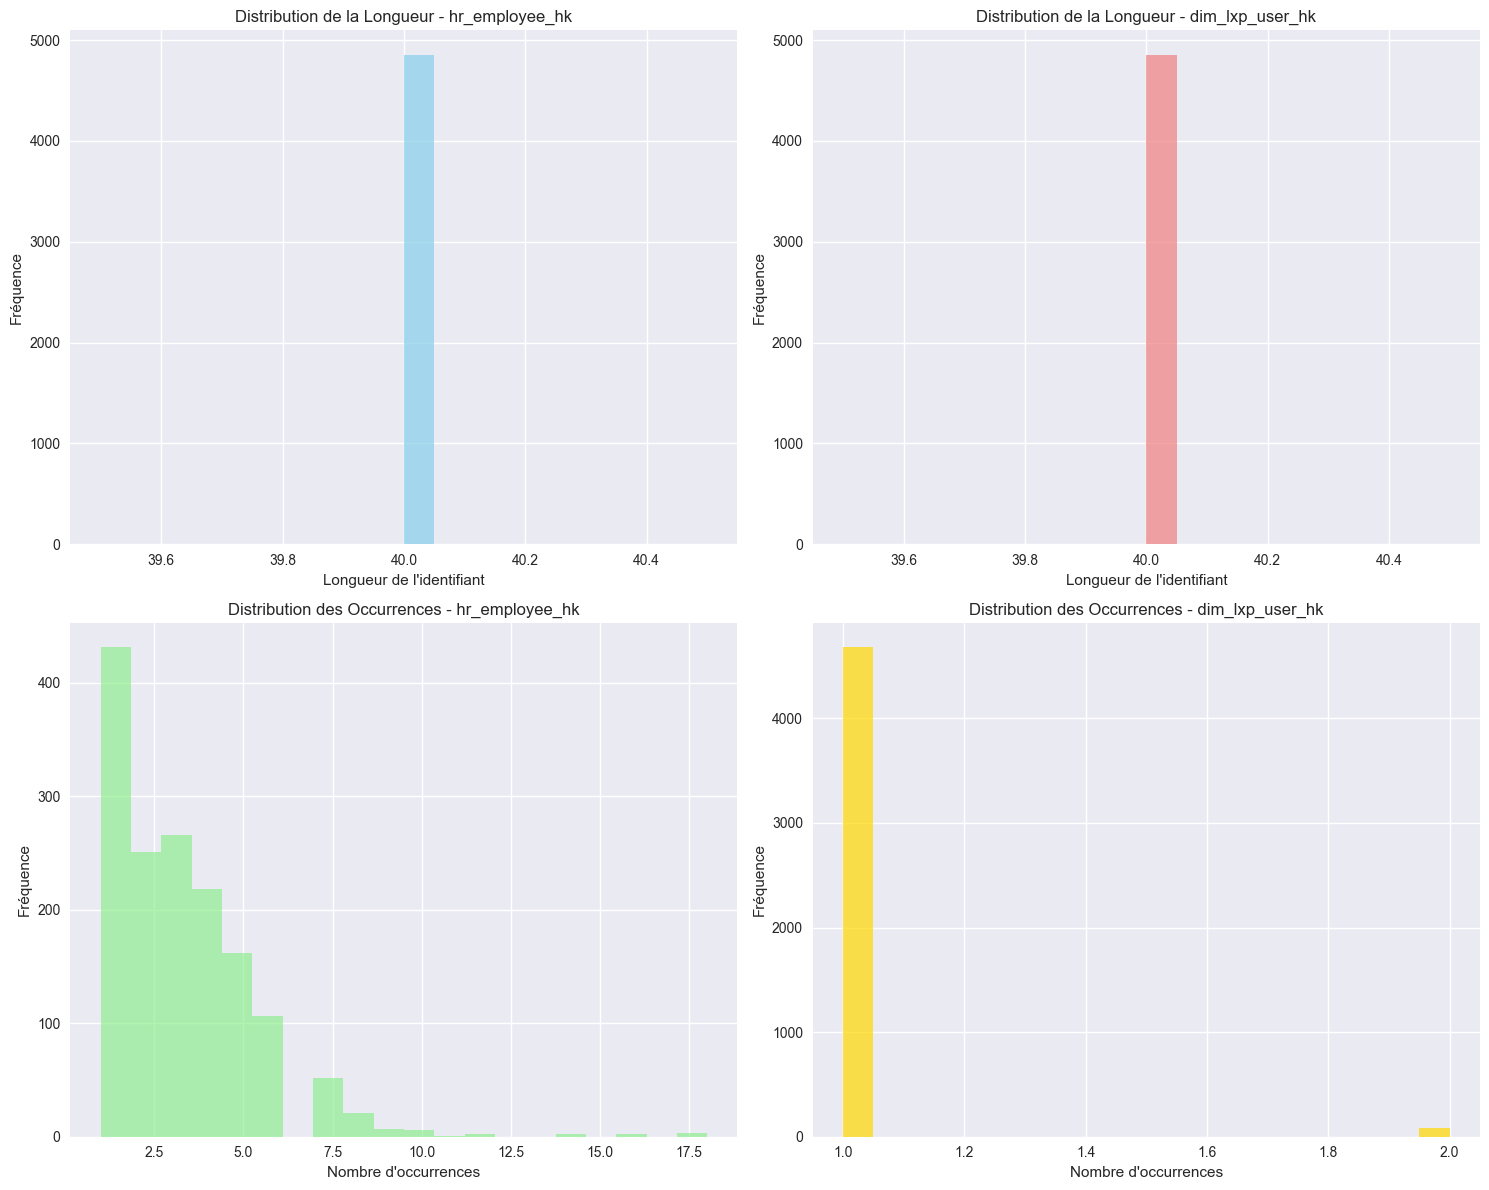

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution des longueurs des identifiants
axes[0,0].hist(df['hr_employee_hk'].str.len(), bins=20, alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribution de la Longueur - hr_employee_hk')
axes[0,0].set_xlabel('Longueur de l\'identifiant')
axes[0,0].set_ylabel('Fréquence')

axes[0,1].hist(df['dim_lxp_user_hk'].str.len(), bins=20, alpha=0.7, color='lightcoral')
axes[0,1].set_title('Distribution de la Longueur - dim_lxp_user_hk')
axes[0,1].set_xlabel('Longueur de l\'identifiant')
axes[0,1].set_ylabel('Fréquence')

# 2. Analyse des doublons
duplicate_hr = df['hr_employee_hk'].value_counts()
duplicate_dim = df['dim_lxp_user_hk'].value_counts()

axes[1,0].hist(duplicate_hr.values, bins=20, alpha=0.7, color='lightgreen')
axes[1,0].set_title('Distribution des Occurrences - hr_employee_hk')
axes[1,0].set_xlabel('Nombre d\'occurrences')
axes[1,0].set_ylabel('Fréquence')

axes[1,1].hist(duplicate_dim.values, bins=20, alpha=0.7, color='gold')
axes[1,1].set_title('Distribution des Occurrences - dim_lxp_user_hk')
axes[1,1].set_xlabel('Nombre d\'occurrences')
axes[1,1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


Je vérifie la longuer des ids pour vérifier si tous est cohérent. Par exemple, je peux voir si il y a un Null au format styring comme identifiant

## Corrélations? 

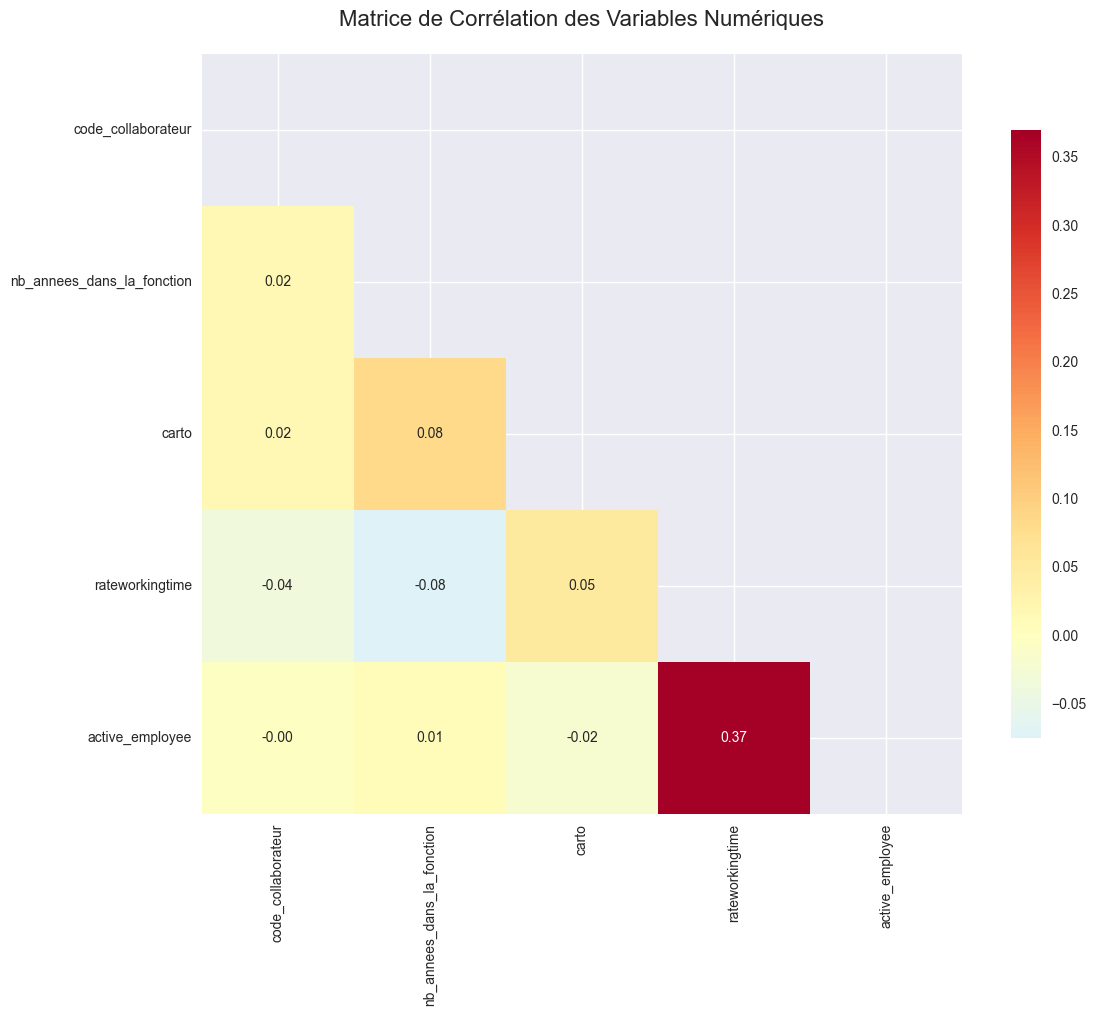

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    # Calcul de la matrice de corrélation
    correlation_matrix = df[numeric_cols].corr()
    
    # Création d'une heatmap avancée
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                center=0,
                square=True,
                fmt='.2f',
                cbar_kws={"shrink": .8})
    
    plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


Rien de très pàertinent.. Passons à l'analyse temporelle

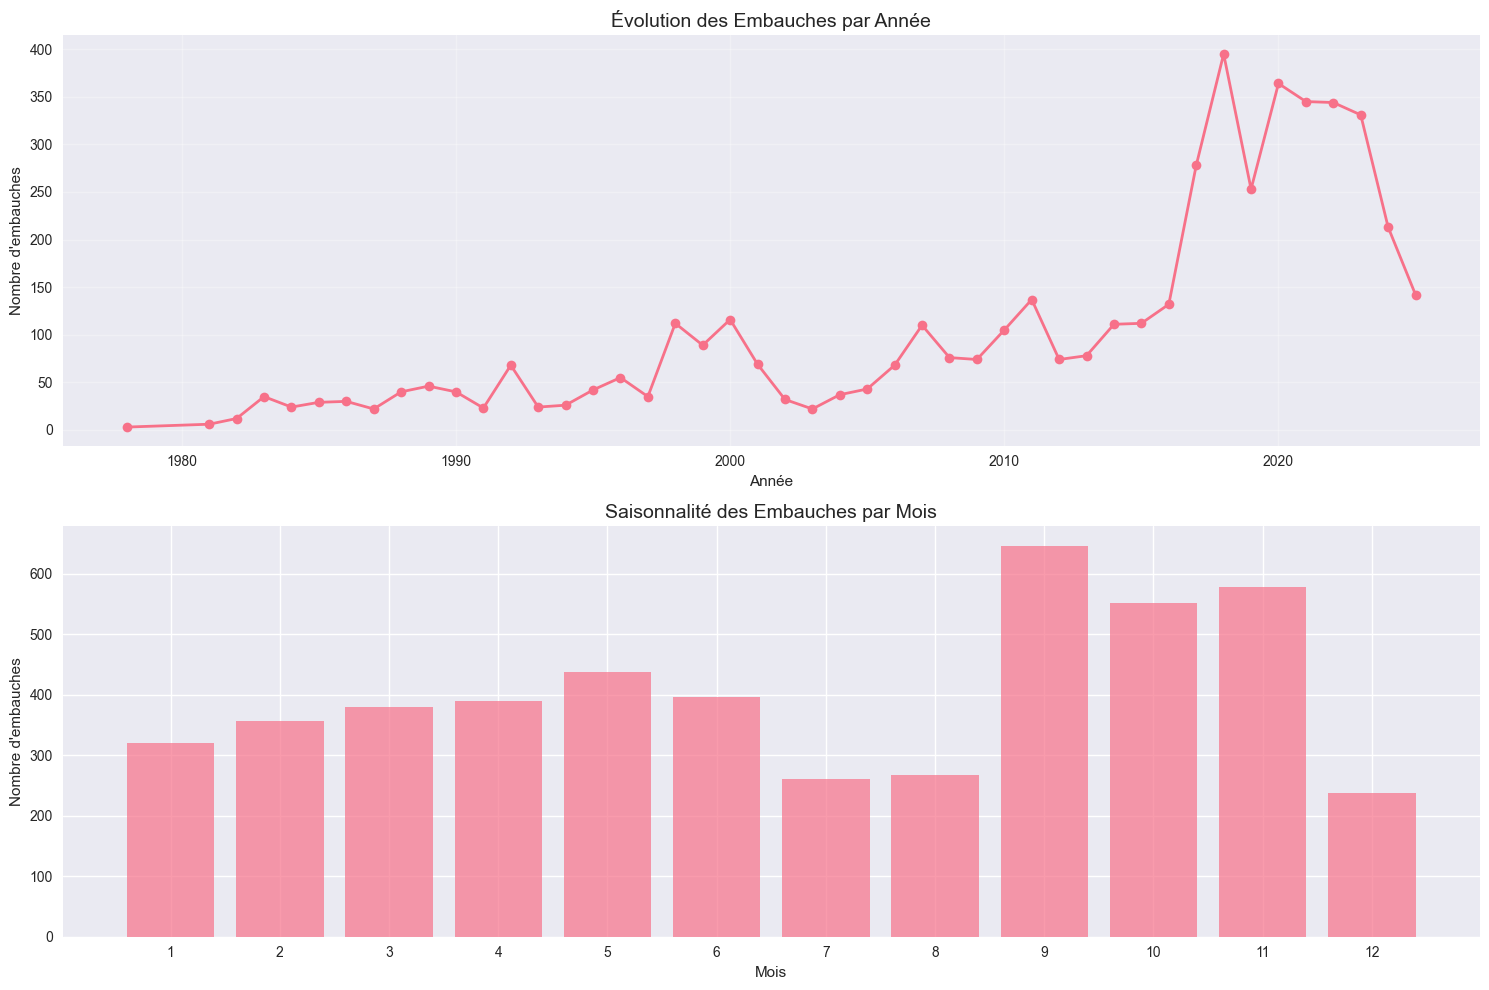

In [18]:
date_columns = ['startedon', 'finishedon']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'startedon' in df.columns:
    df_hired = df.dropna(subset=['startedon'])
    df_hired['year_hired'] = df_hired['startedon'].dt.year
    df_hired['month_hired'] = df_hired['startedon'].dt.month
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    yearly_hires = df_hired['year_hired'].value_counts().sort_index()
    axes[0].plot(yearly_hires.index, yearly_hires.values, marker='o', linewidth=2)
    axes[0].set_title('Évolution des Embauches par Année', fontsize=14)
    axes[0].set_xlabel('Année')
    axes[0].set_ylabel('Nombre d\'embauches')
    axes[0].grid(True, alpha=0.3)
    
    monthly_hires = df_hired['month_hired'].value_counts().sort_index()
    axes[1].bar(monthly_hires.index, monthly_hires.values, alpha=0.7)
    axes[1].set_title('Saisonnalité des Embauches par Mois', fontsize=14)
    axes[1].set_xlabel('Mois')
    axes[1].set_ylabel('Nombre d\'embauches')
    axes[1].set_xticks(range(1, 13))
    
    plt.tight_layout()
    plt.show()


Un graphe assez sympa qui permet de voir l'évolution de la table ;) Voyons les données catégoricales


📊 ANALYSE DE CURRENT_DEPARTEMENT
Nombre de catégories uniques : 13
Top 5 des catégories :
current_departement
PRC      3056
DC&S      328
S&M       309
PIQXL     289
FIN       208


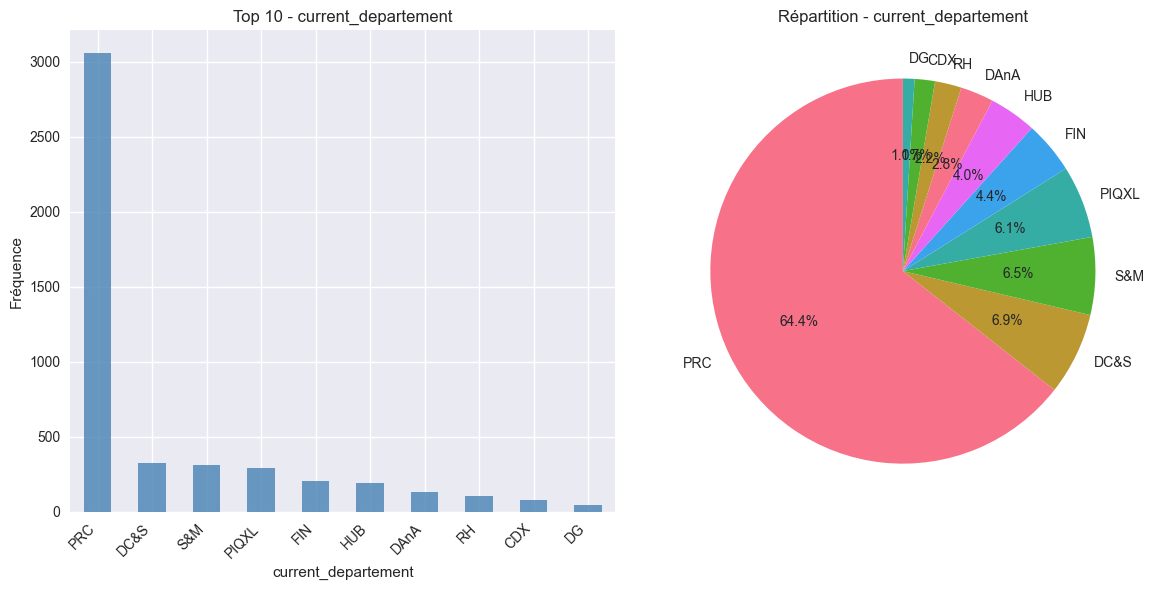


📊 ANALYSE DE CURRENT_FUNCTION
Nombre de catégories uniques : 121
Top 5 des catégories :
current_function
Conseiller Clientèle           685
Customer Care Agent            432
Gestionnaire indemnités        412
Gestionnaire assurabilité      317
Gestionnaire soins de santé    300


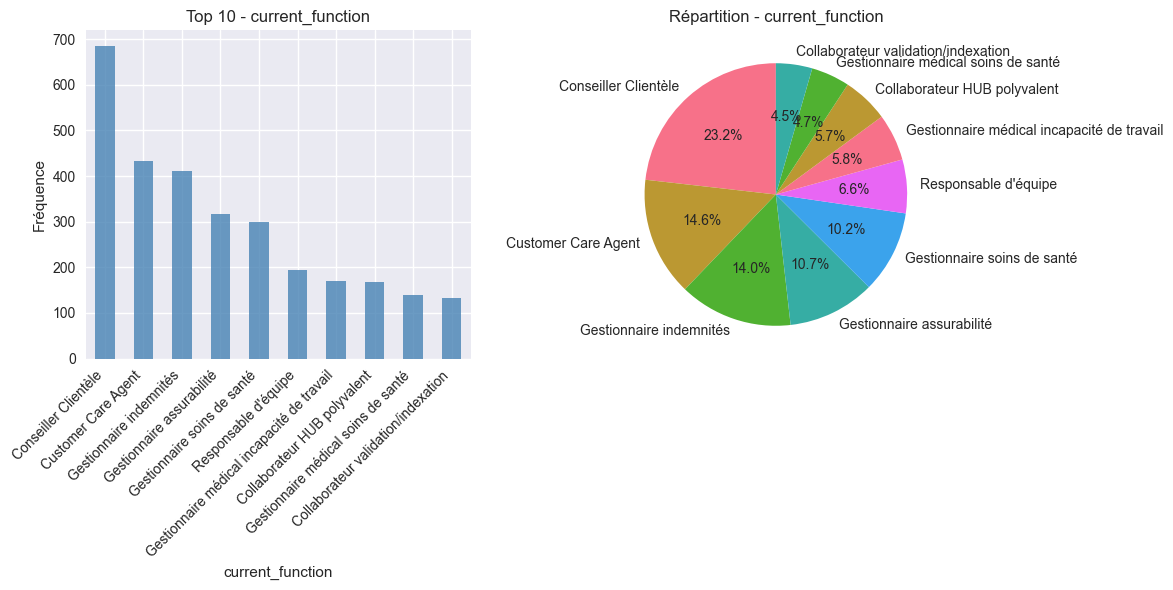


📊 ANALYSE DE CURRENT_EQUIPE
Nombre de catégories uniques : 153
Top 5 des catégories :
current_equipe
PRC - Agence - Wallonie 9    148
PRC - Agence - Wallonie 7    146
PRC - Agence - Wallonie 4    143
PRC - PM - Equipe 3          131
PRC - Assu - Equipe 3        128


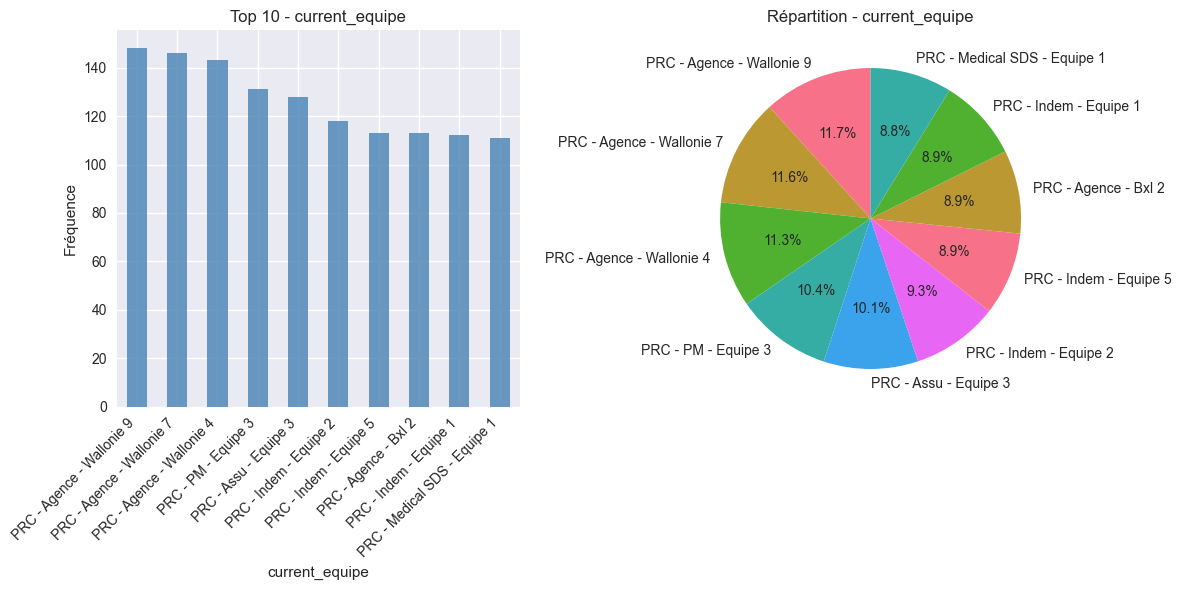


📊 ANALYSE DE EMPLOYER_NAME
Nombre de catégories uniques : 5
Top 5 des catégories :
employer_name
Partena-Mutualité Libre    4650
CIAS                        118
Medexel                      46
Partenamut Externes          34
UCMI                          5


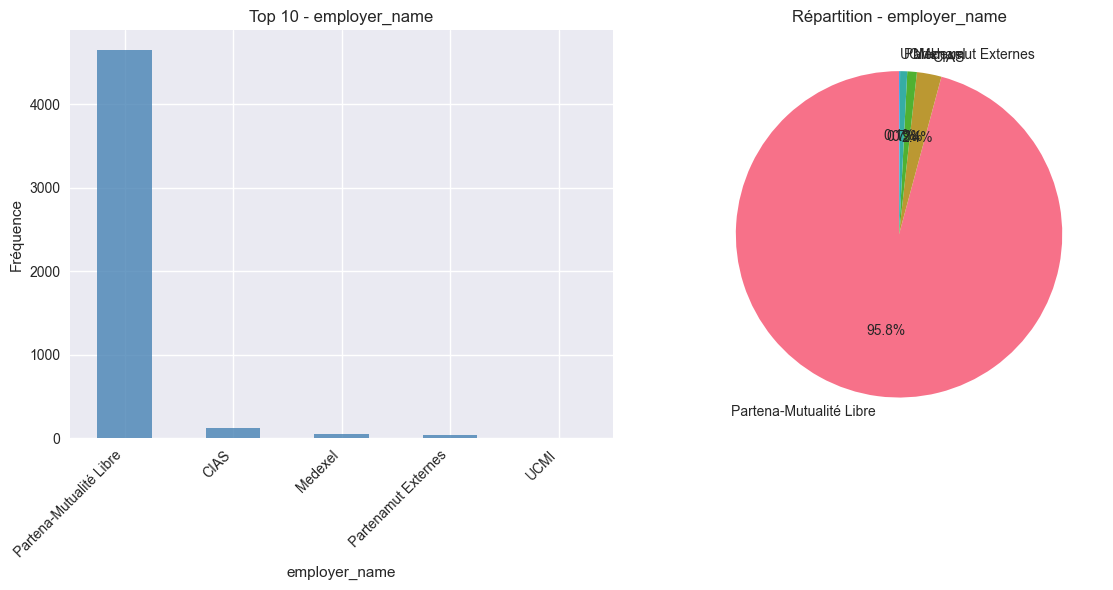

In [ ]:
categorical_cols = ['current_departement', 'current_function', 'current_equipe', 'employer_name']

for col in categorical_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        print(f"\n ANALYSE DE {col.upper()}")
        print("=" * 50)
        
        # Distribution des valeurs
        value_counts = df[col].value_counts()
        print(f"Nombre de catégories uniques : {len(value_counts)}")
        print(f"Top 5 des catégories :")
        print(value_counts.head().to_string())
        
        # Visualisation
        plt.figure(figsize=(12, 6))
        top_10 = value_counts.head(10)
        
        plt.subplot(1, 2, 1)
        top_10.plot(kind='bar', color='steelblue', alpha=0.8)
        plt.title(f'Top 10 - {col}')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Fréquence')
        
        plt.subplot(1, 2, 2)
        plt.pie(top_10.values, labels=top_10.index, autopct='%1.1f%%', startangle=90)
        plt.title(f'Répartition - {col}')
        
        plt.tight_layout()
        plt.show()


Tous ces graphes permettent de se faire une idée de ce qui se trouvce dans les données. Voyons maintenant si nous pouvons détecter des outliers

In [ ]:
def detect_outliers_advanced(df, numeric_cols):
    """
    Détection avancée d'outliers avec plusieurs méthodes
    """
    print("DÉTECTION D'ANOMALIES")
    print("=" * 50)
    
    outliers_summary = {}
    
    for col in numeric_cols:
        if df[col].notna().sum() > 0:
            # Méthode IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            
            # Méthode Z-score
            z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
            outliers_zscore = df[z_scores > 3]
            
            outliers_summary[col] = {
                'iqr_outliers': len(outliers_iqr),
                'zscore_outliers': len(outliers_zscore),
                'total_values': df[col].notna().sum()
            }
            
            print(f"\n{col}:")
            print(f"  • Outliers IQR : {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
            print(f"  • Outliers Z-score : {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")
    
    return outliers_summary

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
outliers_info = detect_outliers_advanced(df, numeric_columns)


🚨 DÉTECTION D'ANOMALIES

code_collaborateur:
  • Outliers IQR : 1222 (25.18%)
  • Outliers Z-score : 21 (0.43%)

nb_annees_dans_la_fonction:
  • Outliers IQR : 278 (5.73%)
  • Outliers Z-score : 129 (2.66%)

carto:
  • Outliers IQR : 701 (14.44%)
  • Outliers Z-score : 0 (0.00%)

rateworkingtime:
  • Outliers IQR : 338 (6.96%)
  • Outliers Z-score : 96 (1.98%)

active_employee:
  • Outliers IQR : 58 (1.20%)
  • Outliers Z-score : 58 (1.20%)


Mouais.. rien de très flagrant. On pouvait s'en douter avec les distributions plus haut !

📋 RAPPORT DE QUALITÉ DES DONNÉES
📊 Informations générales :
   • Nombre de lignes : 4,853
   • Nombre de colonnes : 28
   • Taille mémoire : 6.60 MB

🔍 Top 10 des colonnes avec valeurs manquantes :
                   Colonne  Valeurs_manquantes  Pourcentage
                finishedon                4272    88.028024
              fin_function                1340    27.611787
            user_windowsn1                 110     2.266639
                     carto                 101     2.081187
       current_departement                  60     1.236349
                 startedon                  31     0.638780
               departement                  24     0.494539
            function_group                  23     0.473934
nb_annees_dans_la_fonction                  21     0.432722
              user_windows                   6     0.123635


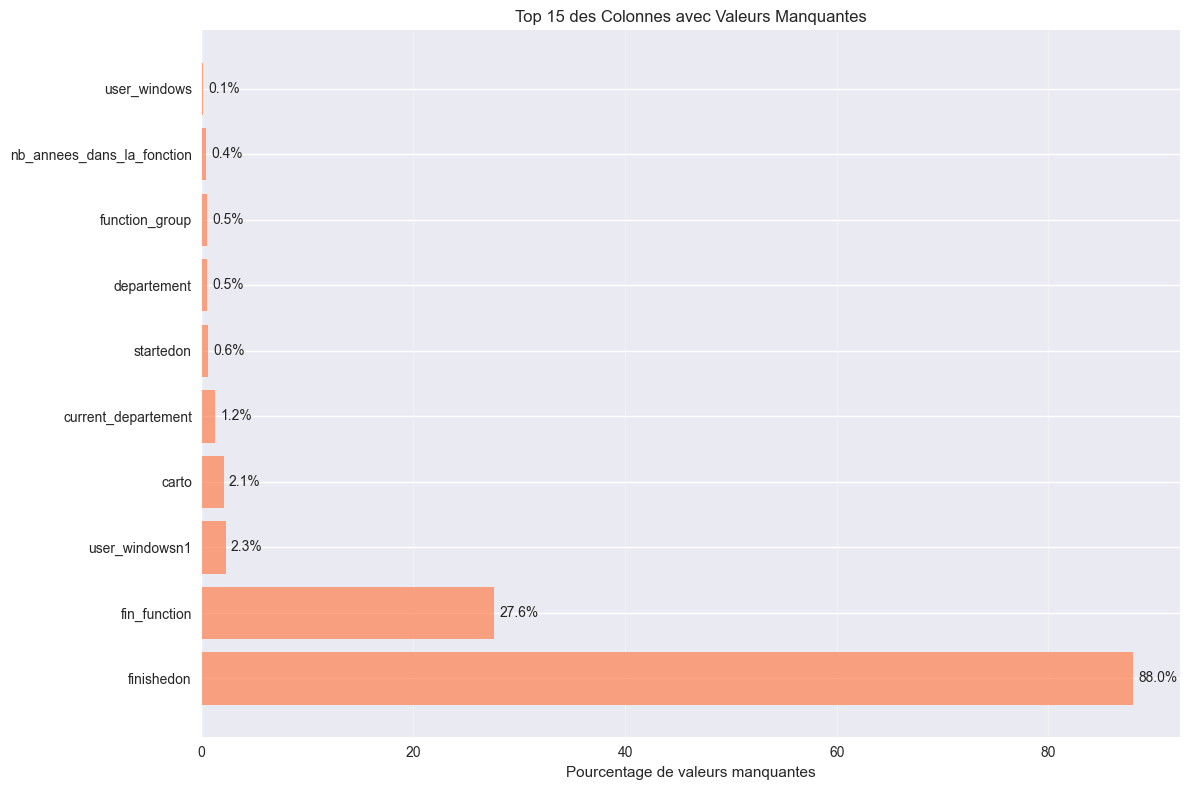

📋 RAPPORT DE QUALITÉ DES DONNÉES
📊 Informations générales :
   • Nombre de lignes : 4,853
   • Nombre de colonnes : 28
   • Taille mémoire : 6.60 MB

🔍 Top 10 des colonnes avec valeurs manquantes :
                   Colonne  Valeurs_manquantes  Pourcentage
                finishedon                4272    88.028024
              fin_function                1340    27.611787
            user_windowsn1                 110     2.266639
                     carto                 101     2.081187
       current_departement                  60     1.236349
                 startedon                  31     0.638780
               departement                  24     0.494539
            function_group                  23     0.473934
nb_annees_dans_la_fonction                  21     0.432722
              user_windows                   6     0.123635


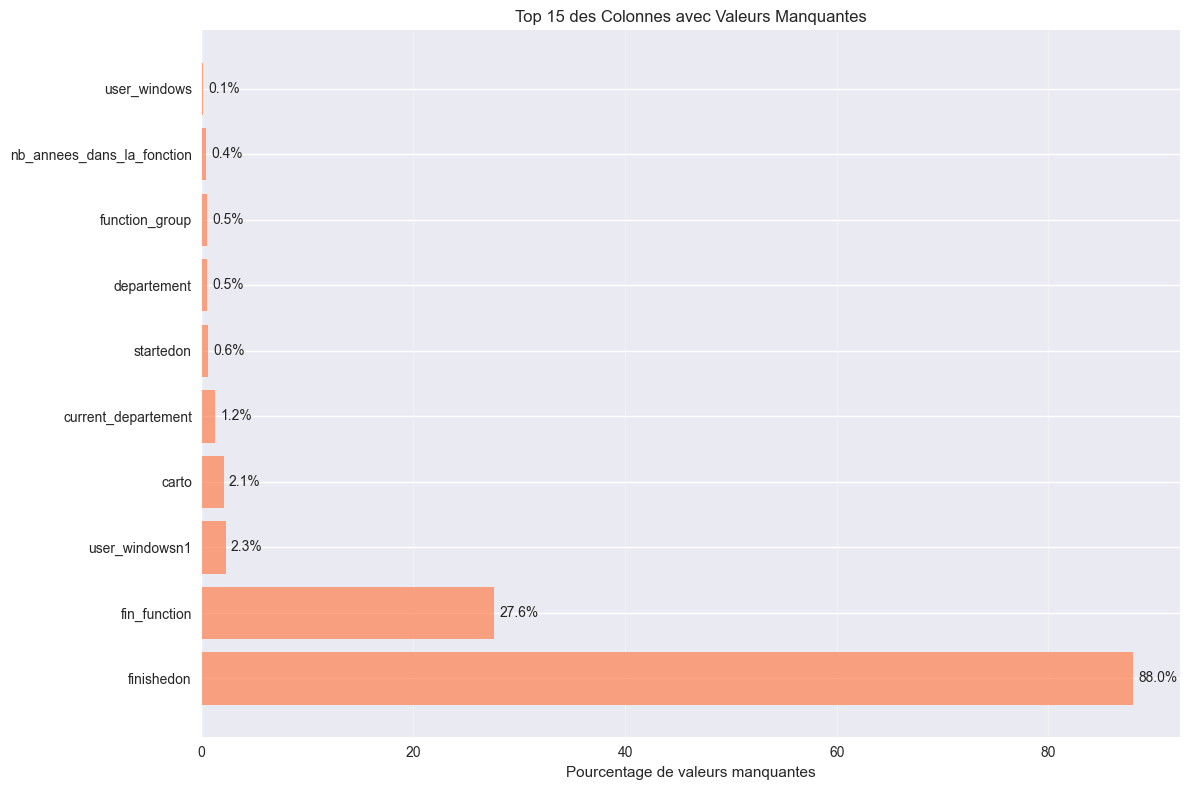

In [ ]:
def generate_data_quality_report(df):
    """
    Génère un rapport complet de qualité des données
    """
    print("RAPPORT DE QUALITÉ DES DONNÉES")
    print("=" * 50)
    
    # Informations générales
    print(f"Informations générales :")
    print(f"   • Nombre de lignes : {len(df):,}")
    print(f"   • Nombre de colonnes : {len(df.columns)}")
    print(f"   • Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Analyse des valeurs manquantes
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Colonne': missing_data.index,
        'Valeurs_manquantes': missing_data.values,
        'Pourcentage': missing_percent.values
    }).sort_values('Pourcentage', ascending=False)
    
    print(f"\n🔍 Top 10 des colonnes avec valeurs manquantes :")
    print(missing_df[missing_df['Valeurs_manquantes'] > 0].head(10).to_string(index=False))
    
    # Visualisation des valeurs manquantes
    plt.figure(figsize=(12, 8))
    top_missing = missing_df[missing_df['Valeurs_manquantes'] > 0].head(15)
    
    plt.barh(range(len(top_missing)), top_missing['Pourcentage'], color='coral', alpha=0.7)
    plt.yticks(range(len(top_missing)), top_missing['Colonne'])
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.title('Top 15 des Colonnes avec Valeurs Manquantes')
    plt.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(top_missing['Pourcentage']):
        plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return missing_df

quality_report = generate_data_quality_report(df)
def generate_data_quality_report(df):
    """
    Génère un rapport complet de qualité des données
    """
    print("RAPPORT DE QUALITÉ DES DONNÉES")
    print("=" * 50)
    
    # Informations générales
    print(f"Informations générales :")
    print(f"   • Nombre de lignes : {len(df):,}")
    print(f"   • Nombre de colonnes : {len(df.columns)}")
    print(f"   • Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Analyse des valeurs manquantes
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Colonne': missing_data.index,
        'Valeurs_manquantes': missing_data.values,
        'Pourcentage': missing_percent.values
    }).sort_values('Pourcentage', ascending=False)
    
    print(f"\n🔍 Top 10 des colonnes avec valeurs manquantes :")
    print(missing_df[missing_df['Valeurs_manquantes'] > 0].head(10).to_string(index=False))
    
    # Visualisation des valeurs manquantes
    plt.figure(figsize=(12, 8))
    top_missing = missing_df[missing_df['Valeurs_manquantes'] > 0].head(15)
    
    plt.barh(range(len(top_missing)), top_missing['Pourcentage'], color='coral', alpha=0.7)
    plt.yticks(range(len(top_missing)), top_missing['Colonne'])
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.title('Top 15 des Colonnes avec Valeurs Manquantes')
    plt.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(top_missing['Pourcentage']):
        plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return missing_df

quality_report = generate_data_quality_report(df)


Ca me parait logique que finishedon soit missing. Je pense que la talbe users ne contient que les données d'employés actifs

# Duplicates

Ici, nous allons d'abord verifier si les données contiennent des duplicates évidents, càd deux lignes exactement pareilles. 

In [23]:
nombre_de_lignes_dupliquees = df.duplicated().value_counts()
nombre_de_lignes_dupliquees

False    4853
Name: count, dtype: int64

Il n'y a pas de lignes dupliquées. Tachons de voir si il y a des sous-groupes dupliqués? 
<br> Je commence avec les colonnes de dimensions, car ce sont les colonnes qui me serviront à faire mon JOIN plus tard dans le projet.

In [24]:
cols_to_check = ['dim_lxp_user_hk', 'hr_employee_hk']
duplicate_data = pd.DataFrame({
    'Colonne': cols_to_check,
    'Valeurs_dupliquees': [df[col].duplicated().sum() for col in cols_to_check],
    'Pourcentage': [df[col].duplicated().mean() * 100 for col in cols_to_check],
    'Type_données': [df[col].dtype for col in cols_to_check]
})

duplicate_data = duplicate_data[duplicate_data['Valeurs_dupliquees'] > 0].sort_values('Valeurs_dupliquees', ascending=False)
print("\n=== DOUBLONS PAR COLONNE ===")
print(duplicate_data)


=== DOUBLONS PAR COLONNE ===
           Colonne  Valeurs_dupliquees  Pourcentage Type_données
1   hr_employee_hk                3323    68.473109       object
0  dim_lxp_user_hk                  87     1.792706       object


Ok, nous voyons qu'il y a 86 lignes dupliquées pour la dim user, ce qui signifie qu'il y a 86 lignes où la dimension user partage un employee key. Cela parait suspect. Le nombre étant assez faible, je vais exporter le fichier pour l'ouvrir dans Excel. 

In [26]:
df[df['dim_lxp_user_hk'].duplicated()].to_csv('duplicated_users.csv')

J'ai effectivement trouvé des users qui partagent une seule key employee. Je pense que cela est possible, si un utilisateur change de fonction par exemple.

Voyons maintenant dans l'autre sens, aka des employees qui ont des données différentes. 

In [27]:
df[df['hr_employee_hk'].duplicated(keep=False)].sort_values(by='hr_employee_hk')

,dim_lxp_user_hk,hr_employee_hk,user_windows,code_collaborateur,lastname,firstname,user_windowsn1,equipe,code_equipe,departement,function,code_function,function_group,debut_function,fin_function,nb_annees_dans_la_fonction,carto,rateworkingtime,startedon,finishedon,active_employee,employer_name,current_equipe,current_code_equipe,current_departement,current_function,current_code_function,current_function_group
4477,68e4ce1217533bce505378ff76d4e6f334c9427d,006838930b7042b303cc7f8ebb3d46eddcc4f620,M509MSLI,21450,Garnier,Cipriano,M509CHON,PRC - PM - Equipe 4,414060,PRC,Gestionnaire soins de santé,F0059,Collaborateur,2024-09-04,2025-03-03,0.49,3.0,100.0,2023-09-04,2025-09-03,1,Partena-Mutualité Libre,PRC - PM - Equipe 4,414060,PRC,Gestionnaire soins de santé,F0059,Collaborateur
4095,ba3b57624703b2c5a44cc01a5f607ddafa1327bf,006838930b7042b303cc7f8ebb3d46eddcc4f620,M509MSLI,21450,Garnier,Cipriano,M509CHON,FIN - Facility Batiments,112000,FIN,Collaborateur Facility,F0123,Collaborateur,2022-12-26,NaN,2.52,2.0,100.0,2022-09-26,NaT,1,Partena-Mutualité Libre,FIN - Facility Batiments,112000,FIN,Collaborateur Facility,F0123,Collaborateur
4155,e8ee8ff84f235efbd61d2015c67f9714297656eb,00842851ed0af60fcc4d4566e62c2f2631cf9906,M509CBEE,19344,Lourenço,Ana,M527JKAA,HUB - Opérations HUB - Equipe 2,915011,HUB,Collaborateur HUB polyvalent,F0089,Collaborateur,2023-11-20,2024-05-19,0.49,2.0,100.0,2023-11-20,2025-11-19,1,Partena-Mutualité Libre,HUB - Opérations HUB - Equipe 2,915011,HUB,Collaborateur HUB polyvalent,F0089,Collaborateur
3208,87c115b1bbbf4acf13d5f4eeecb5679db2dca8ca,00842851ed0af60fcc4d4566e62c2f2631cf9906,M509CBEE,19344,Lourenço,Ana,M527JKAA,DC&S - Ergothérapie,532040,DC&S,Ergothérapeute,F0045,Collaborateur,2017-12-01,2021-03-31,3.33,5.0,100.0,2015-01-05,2025-08-17,1,CIAS,DC&S - Gestion des projets,531030,DC&S,Responsable de projets,F0073,MatriX
1882,76f47293e561c0f2c0b93f47d545ad2409ebfecd,00842851ed0af60fcc4d4566e62c2f2631cf9906,M509CBEE,19344,Lourenço,Ana,M527JKAA,PRC - Service Center - Equipe 3,525030,PRC,Customer Care Agent,F0081,Collaborateur,2017-12-01,2018-05-31,0.49,4.0,100.0,2014-09-29,NaT,1,Partena-Mutualité Libre,CDX - Business Analyses & User Acceptance,515080,CDX,Business application owner,F0139,MatriX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3689,7996fd4b1b21cb5a0247b6cfd4872639c4abf3aa,ff9a50a08a7833f2a69f34b9f5cb6af8d5ebaaee,M509RCEC,19722,العقيل,Frédérique,M509MPOL,PRC - Assu - Equipe 1,412010,PRC,Gestionnaire assurabilité,F0049,Collaborateur,2021-11-03,2022-05-02,0.49,4.0,100.0,2021-05-03,NaT,1,Partena-Mutualité Libre,PRC - Assu - Equipe 1,412010,PRC,Gestionnaire assurabilité,F0049,Collaborateur
656,eb2f0943dfef955cd1195d4b227acfcc96a109a7,ff9a50a08a7833f2a69f34b9f5cb6af8d5ebaaee,M509RCEC,19722,العقيل,Frédérique,M509MPOL,PRC - SMA - Claims Dentalia 1,414031,PRC,Gestionnaire Soins de santé SMA,F0060,Collaborateur,2021-06-03,NaN,4.08,3.0,100.0,2019-06-03,NaT,1,Partena-Mutualité Libre,PRC - SMA - Claims Dentalia 1,414031,PRC,Gestionnaire Soins de santé SMA,F0060,Collaborateur
726,b8d45f92f60eae20c05039f864cec68bb60e763d,ff9a50a08a7833f2a69f34b9f5cb6af8d5ebaaee,M509RCEC,19722,العقيل,Frédérique,M509MPOL,PRC - Agence - Bxl 2,522020,PRC,Conseiller Clientèle,F0031,Collaborateur,2022-09-06,2023-03-05,0.49,5.0,100.0,2021-09-06,NaT,1,Partena-Mutualité Libre,PRC - Agence - Bxl 2,522020,PRC,Conseiller Clientèle,F0031,Collaborateur
3820,a5dbfd53735ed57c982d4c6753e01453620c8853,ff9a50a08a7833f2a69f34b9f5cb6af8d5ebaaee,M509RCEC,19722,العقيل,Frédérique,M509MPOL,DC&S - Service social Bruxelles,532020,DC&S,Travailleur social,F0083,Collaborateur,2025-04-22,NaN,0.19,5.0,100.0,2024-04-22,2025-04-21,1,Partena-Mutualité Libre,DC&S - Service social Bruxelles,532020,DC&S,Travailleur social,F0083,Collaborateur


## Sanity checks et counts

In [29]:
counts_per_departement = df.groupby('departement')['dim_lxp_user_hk'].count().sort_values(ascending=False)
counts_per_departement

departement
PRC      3173
HUB       326
S&M       275
DC&S      257
PIQXL     227
FIN       168
RH        110
DAnA       99
CDX        54
MXL        32
DG         26
DGA        24
MKT        18
DAP        15
S&DO       13
JUR         7
C&O         4
OPI         1
Name: dim_lxp_user_hk, dtype: int64

In [30]:
counts_per_employer = df.groupby('employer_name')['dim_lxp_user_hk'].count().sort_values(ascending=False)
counts_per_employer



employer_name
Partena-Mutualité Libre    4650
CIAS                        118
Medexel                      46
Partenamut Externes          34
UCMI                          5
Name: dim_lxp_user_hk, dtype: int64

Ok, mais je sais que un employé peut avoir plusieurs clefs user...

In [33]:
counts_per_employer = users.groupby('employer_name')['hr_employee_hk'].count().sort_values(ascending=False)
counts_per_employer

employer_name
Partena-Mutualité Libre    4650
CIAS                        118
Medexel                      46
Partenamut Externes          34
UCMI                          5
Name: hr_employee_hk, dtype: int64

In [ ]:
counts_per_employer = df.groupby('current_departement')['hr_employee_hk'].nunique().sort_values(ascending=False)
print("Le nombre d'emmployés total est de : {}".format(counts_per_employer.sum()))

Le nombre d'emmployés total est de : 2904


# Lien avec la facts

In [32]:
facts = pd.read_csv("../data/facts_edited.csv", sep = '|')
facts.columns

Index(['Unnamed: 0', 'dim_lxp_user_hk', 'dim_lxp_training_hk',
       'dim_lxp_session_hk', 'lxp_session_hk', 'lxp_session_bk',
       'dim_lxp_meeting_session_hk', 'lxp_meeting_session_hk',
       'lxp_meeting_session_bk', 'dim_lxp_training_provider_hk',
       'lxp_training_provider_bk', 'user_windows', 'user_name',
       'training_name', 'session_name', 'meeting_session_name', 'status',
       'begin', 'end', 'duration_hours', 'traineepresence', 'absencejustified',
       'absencereason', 'presence_hours', 'training_learningmode',
       'session_learningmode', 'meetingsession_meetingmode', 'lmsaccesscount',
       'lmstimespend', 'lmsprogresspercent', 'calculated_time',
       'attendance_date'],
      dtype='object')

## Analyse de la jointure

In [36]:
def analyze_referential_integrity(dim_df, facts_df):
    """
    Analyse l'intégrité référentielle entre DIM USER et FACTS
    """
    print("ANALYSE DE L'INTÉGRITÉ RÉFÉRENTIELLE")
    print("=" * 50)
    
    # Identifiants uniques dans chaque table
    dim_users = set(dim_df['dim_lxp_user_hk'].dropna())
    facts_users = set(facts_df['dim_lxp_user_hk'].dropna())
    
    # Analyse des intersections
    common_users = dim_users.intersection(facts_users)
    dim_only = dim_users - facts_users
    facts_only = facts_users - dim_users
    
    print(f"📊 Statistiques de jointure :")
    print(f"   • Utilisateurs dans DIM uniquement : {len(dim_only):,}")
    print(f"   • Utilisateurs dans FACTS uniquement : {len(facts_only):,}")
    print(f"   • Utilisateurs communs : {len(common_users):,}")
    print(f"   • Taux de couverture DIM→FACTS : {len(common_users)/len(dim_users)*100:.1f}%")
    print(f"   • Taux de couverture FACTS→DIM : {len(common_users)/len(facts_users)*100:.1f}%")
    
    # Détection des orphelins
    if len(facts_only) > 0:
        print(f"\n⚠️  ATTENTION : {len(facts_only)} utilisateurs orphelins dans FACTS")
        print("   Ces enregistrements n'ont pas de correspondance dans DIM USER")
    
    if len(dim_only) > 0:
        print(f"\n💡 INFO : {len(dim_only)} utilisateurs sans activité dans FACTS")
        print("   Ces utilisateurs n'ont pas encore de formations enregistrées")
    
    return {
        'common_users': common_users,
        'dim_only': dim_only,
        'facts_only': facts_only
    }

# Exécution de l'analyse
integrity_analysis = analyze_referential_integrity(df, facts)


ANALYSE DE L'INTÉGRITÉ RÉFÉRENTIELLE
📊 Statistiques de jointure :
   • Utilisateurs dans DIM uniquement : 1,075
   • Utilisateurs dans FACTS uniquement : 155
   • Utilisateurs communs : 3,691
   • Taux de couverture DIM→FACTS : 77.4%
   • Taux de couverture FACTS→DIM : 96.0%

⚠️  ATTENTION : 155 utilisateurs orphelins dans FACTS
   Ces enregistrements n'ont pas de correspondance dans DIM USER

💡 INFO : 1075 utilisateurs sans activité dans FACTS
   Ces utilisateurs n'ont pas encore de formations enregistrées


## Jointure et enrichissement df

In [37]:
def create_enriched_dataset(dim_df, facts_df):
    """
    Crée un dataset enrichi en joignant DIM USER et FACTS
    """
    print("🔄 CRÉATION DU DATASET ENRICHI")
    print("=" * 50)
    
    # Jointure LEFT pour conserver tous les utilisateurs de la dimension
    enriched_df = facts_df.merge(
        dim_df, 
        on='dim_lxp_user_hk', 
        how='left',
        suffixes=('_facts', '_dim')
    )
    
    print(f"Dataset enrichi créé : {len(enriched_df):,} lignes")
    
    # Conversion des dates
    date_columns = ['begin', 'end', 'attendance_date']
    for col in date_columns:
        if col in enriched_df.columns:
            enriched_df[col] = pd.to_datetime(enriched_df[col], errors='coerce')

    if 'begin' in enriched_df.columns and 'end' in enriched_df.columns:
        enriched_df['session_duration_calculated'] = (
            enriched_df['end'] - enriched_df['begin']
        ).dt.total_seconds() / 3600  # en heures
    
    return enriched_df

enriched_data = create_enriched_dataset(df, facts)


🔄 CRÉATION DU DATASET ENRICHI
Dataset enrichi créé : 71,183 lignes


## Pattenr par utiliszteur

In [38]:
def analyze_user_activity_patterns(enriched_df):
    """
    Analyse les patterns d'activité des utilisateurs
    """
    print("📈 ANALYSE DES PATTERNS D'ACTIVITÉ")
    print("=" * 50)
    
    # Agrégation par utilisateur
    user_stats = enriched_df.groupby('dim_lxp_user_hk').agg({
        'training_name': 'nunique',
        'session_name': 'nunique',
        'duration_hours': ['sum', 'mean', 'count'],
        'presence_hours': 'sum',
        'lmsaccesscount': 'sum',
        'lmstimespend': 'sum',
        'lmsprogresspercent': 'mean',
        'status': lambda x: (x == 'completed').sum(),
        'traineepresence': lambda x: (x == 'present').sum(),
        'attendance_date': ['min', 'max']
    }).round(2)
    
    # Aplatissement des colonnes multi-niveaux
    user_stats.columns = [
        'formations_uniques', 'sessions_uniques', 'duree_totale_h', 
        'duree_moyenne_h', 'nb_sessions', 'presence_totale_h',
        'acces_lms_total', 'temps_lms_total', 'progres_moyen_pct',
        'formations_completees', 'presences_confirmees', 
        'premiere_formation', 'derniere_formation'
    ]
    
    # Calcul de métriques d'engagement
    user_stats['taux_completion'] = (
        user_stats['formations_completees'] / user_stats['nb_sessions'] * 100
    ).round(1)
    
    user_stats['taux_presence'] = (
        user_stats['presences_confirmees'] / user_stats['nb_sessions'] * 100
    ).round(1)
    
    # Période d'activité en jours
    user_stats['periode_activite_jours'] = (
        user_stats['derniere_formation'] - user_stats['premiere_formation']
    ).dt.days
    
    print("📊 Statistiques d'activité par utilisateur :")
    print(user_stats.describe())
    
    return user_stats

user_activity = analyze_user_activity_patterns(enriched_data)


📈 ANALYSE DES PATTERNS D'ACTIVITÉ
📊 Statistiques d'activité par utilisateur :
       formations_uniques  sessions_uniques  duree_totale_h  duree_moyenne_h  \
count         3846.000000       3846.000000     3846.000000      3846.000000   
mean            15.885075         16.239470       63.662855         3.852444   
min              1.000000          1.000000        0.170000         0.170000   
25%              4.000000          4.000000       14.000000         2.080000   
50%             10.000000         10.000000       36.585000         3.320000   
75%             22.000000         23.000000       87.750000         5.000000   
max            100.000000        118.000000      544.500000        32.000000   
std             17.058663         17.144171       73.872400         2.531635   

       nb_sessions  presence_totale_h  acces_lms_total  temps_lms_total  \
count  3846.000000        3846.000000      3846.000000      3846.000000   
mean     18.505200          59.748341         3.039

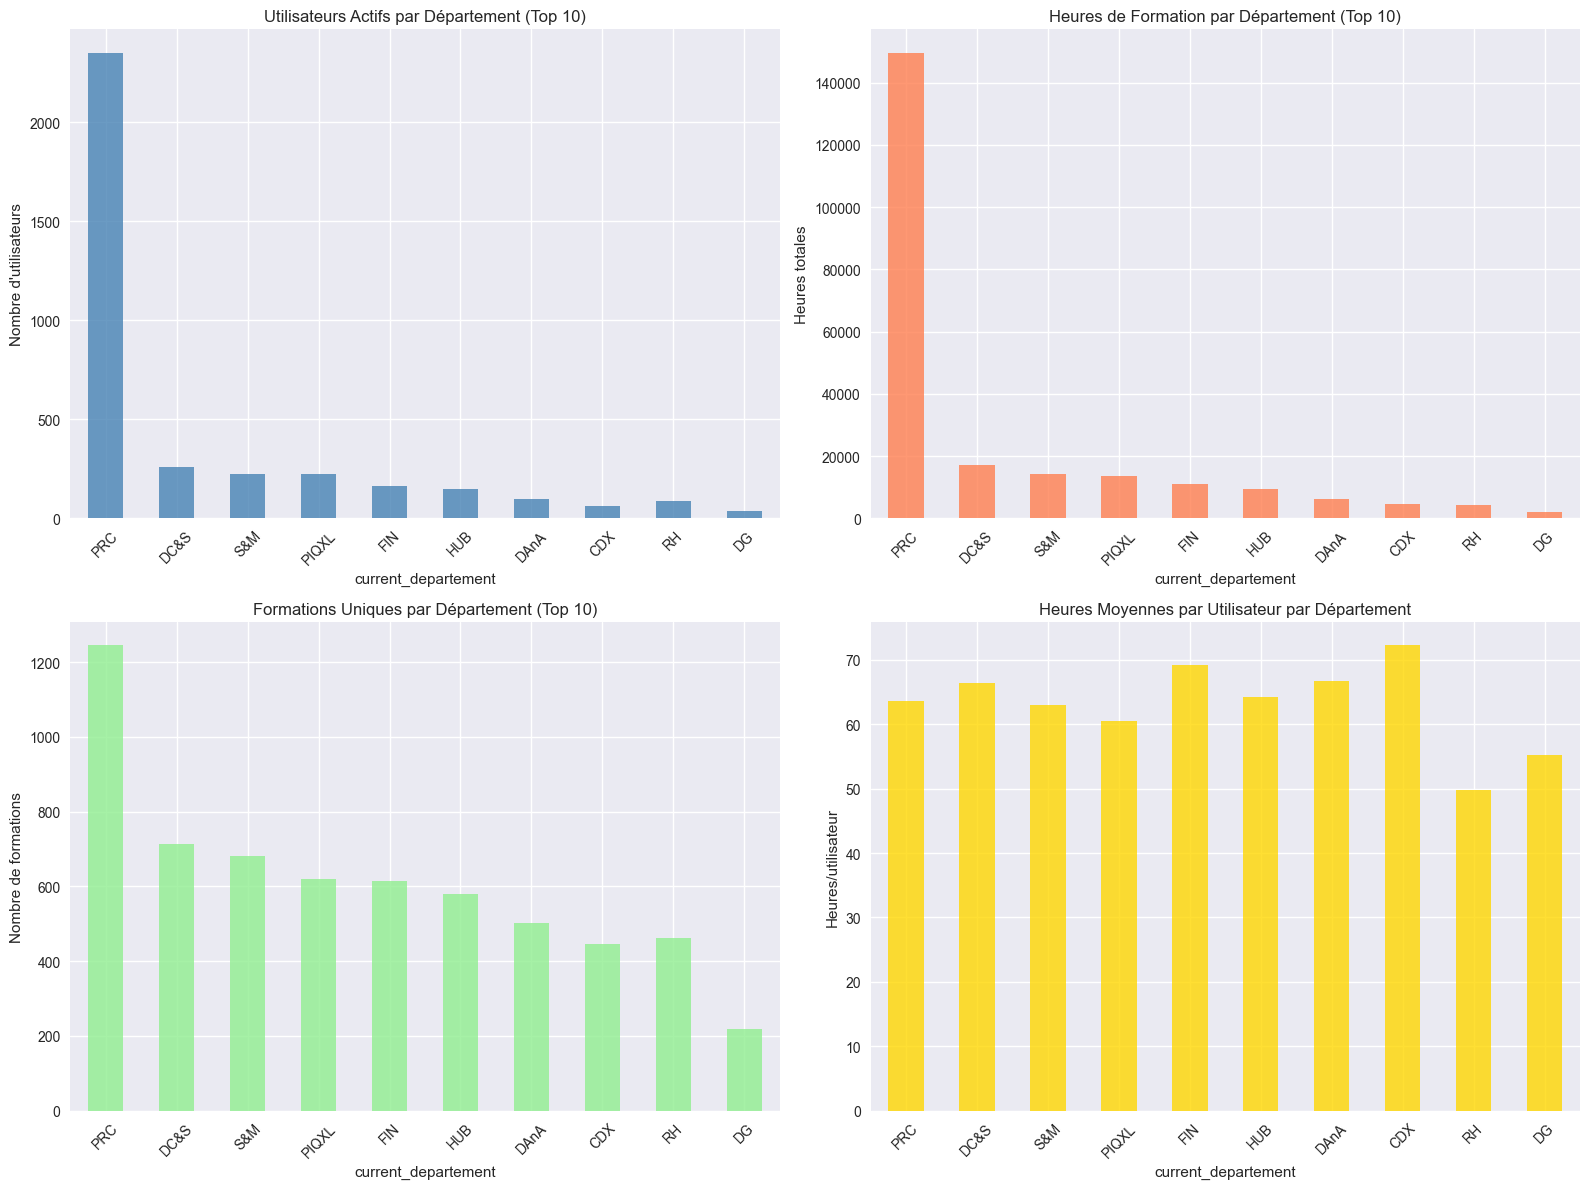

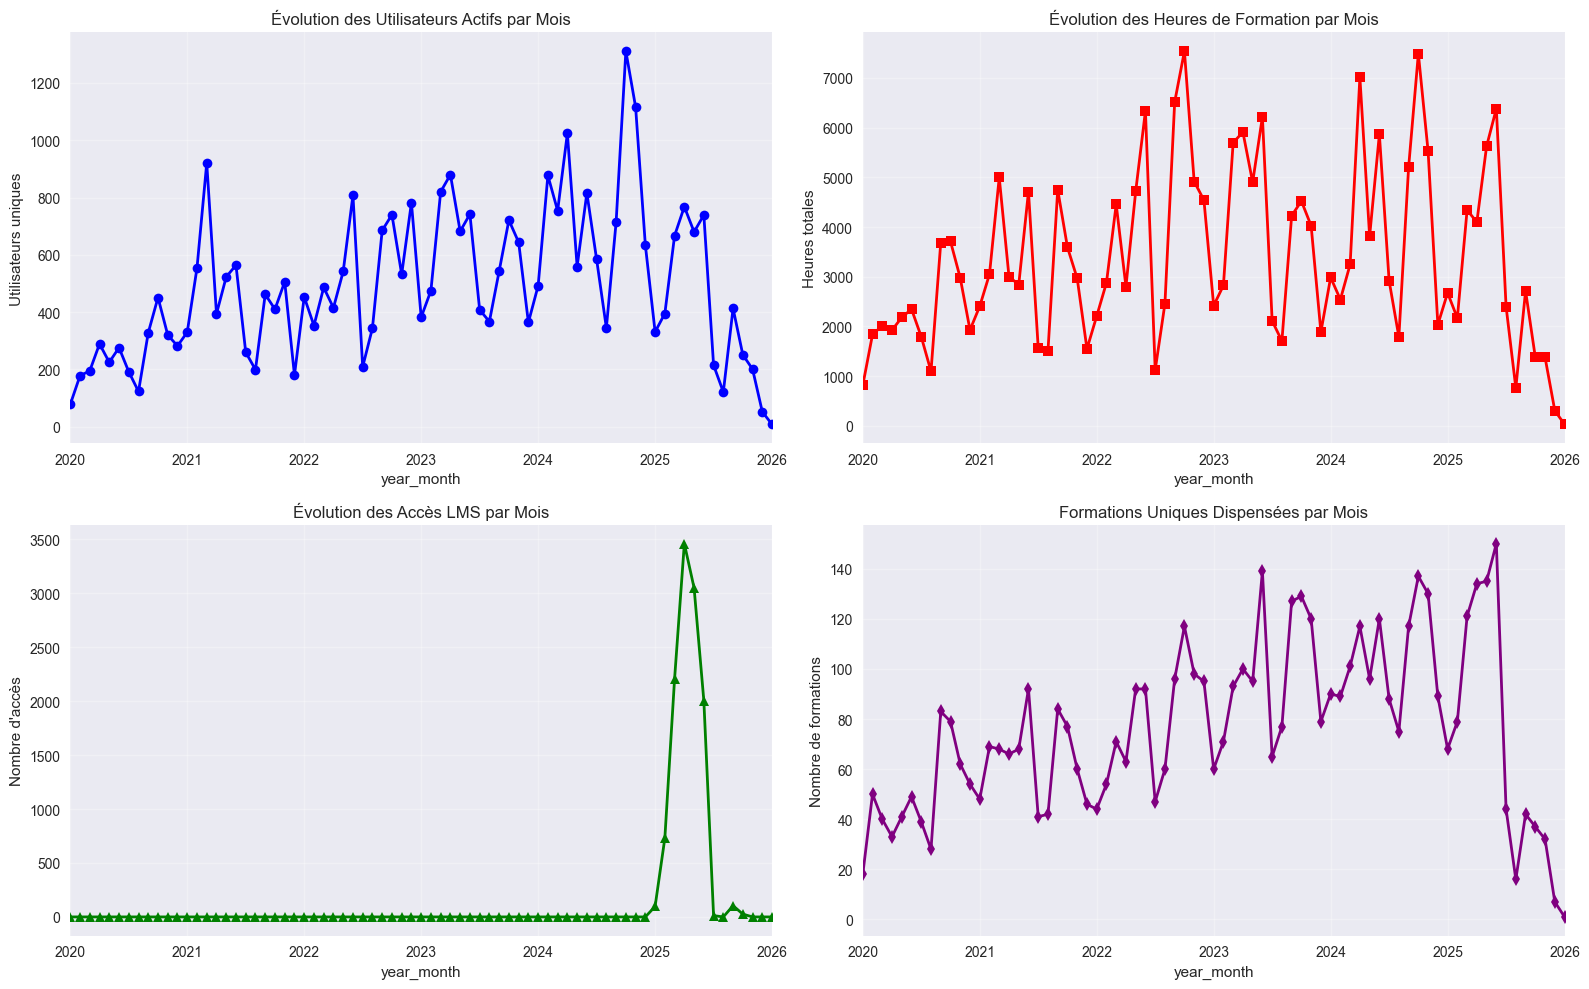

In [39]:
# =============================================================================
# VISUALISATIONS CROISÉES DIM USER ↔ FACTS
# =============================================================================

# 1. Distribution de l'activité par département
if 'current_departement' in enriched_data.columns:
    dept_activity = enriched_data.groupby('current_departement').agg({
        'dim_lxp_user_hk': 'nunique',
        'duration_hours': 'sum',
        'training_name': 'nunique'
    }).sort_values('duration_hours', ascending=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Nombre d'utilisateurs actifs par département
    dept_activity['dim_lxp_user_hk'].head(10).plot(
        kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8
    )
    axes[0,0].set_title('Utilisateurs Actifs par Département (Top 10)')
    axes[0,0].set_ylabel('Nombre d\'utilisateurs')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Heures totales de formation par département
    dept_activity['duration_hours'].head(10).plot(
        kind='bar', ax=axes[0,1], color='coral', alpha=0.8
    )
    axes[0,1].set_title('Heures de Formation par Département (Top 10)')
    axes[0,1].set_ylabel('Heures totales')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Formations uniques par département
    dept_activity['training_name'].head(10).plot(
        kind='bar', ax=axes[1,0], color='lightgreen', alpha=0.8
    )
    axes[1,0].set_title('Formations Uniques par Département (Top 10)')
    axes[1,0].set_ylabel('Nombre de formations')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Ratio heures/utilisateur par département
    dept_ratio = (dept_activity['duration_hours'] / dept_activity['dim_lxp_user_hk']).head(10)
    dept_ratio.plot(kind='bar', ax=axes[1,1], color='gold', alpha=0.8)
    axes[1,1].set_title('Heures Moyennes par Utilisateur par Département')
    axes[1,1].set_ylabel('Heures/utilisateur')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# 2. Analyse temporelle de l'engagement
if 'attendance_date' in enriched_data.columns:
    enriched_data['year_month'] = enriched_data['attendance_date'].dt.to_period('M')
    
    monthly_stats = enriched_data.groupby('year_month').agg({
        'dim_lxp_user_hk': 'nunique',
        'duration_hours': 'sum',
        'lmsaccesscount': 'sum',
        'training_name': 'nunique'
    })
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Évolution des utilisateurs actifs
    monthly_stats['dim_lxp_user_hk'].plot(
        ax=axes[0,0], marker='o', linewidth=2, color='blue'
    )
    axes[0,0].set_title('Évolution des Utilisateurs Actifs par Mois')
    axes[0,0].set_ylabel('Utilisateurs uniques')
    axes[0,0].grid(True, alpha=0.3)
    
    # Évolution des heures de formation
    monthly_stats['duration_hours'].plot(
        ax=axes[0,1], marker='s', linewidth=2, color='red'
    )
    axes[0,1].set_title('Évolution des Heures de Formation par Mois')
    axes[0,1].set_ylabel('Heures totales')
    axes[0,1].grid(True, alpha=0.3)
    
    # Accès LMS par mois
    monthly_stats['lmsaccesscount'].plot(
        ax=axes[1,0], marker='^', linewidth=2, color='green'
    )
    axes[1,0].set_title('Évolution des Accès LMS par Mois')
    axes[1,0].set_ylabel('Nombre d\'accès')
    axes[1,0].grid(True, alpha=0.3)
    
    # Formations uniques par mois
    monthly_stats['training_name'].plot(
        ax=axes[1,1], marker='d', linewidth=2, color='purple'
    )
    axes[1,1].set_title('Formations Uniques Dispensées par Mois')
    axes[1,1].set_ylabel('Nombre de formations')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## ANalyse qualityé jointure

In [40]:
def analyze_cross_data_quality(enriched_df):
    """
    Analyse la qualité des données dans le dataset croisé
    """
    print("ANALYSE DE QUALITÉ DES DONNÉES CROISÉES")
    print("=" * 50)
    
    # Cohérence des durées
    duration_issues = enriched_df[
        (enriched_df['duration_hours'] > 0) & 
        (enriched_df['presence_hours'] > enriched_df['duration_hours'])
    ]
    
    print(f"⚠️  Incohérences de durée :")
    print(f"   • Sessions où presence_hours > duration_hours : {len(duration_issues)}")
    
    # Cohérence des statuts
    status_presence_issues = enriched_df[
        (enriched_df['status'] == 'completed') & 
        (enriched_df['traineepresence'] == 'absent')
    ]
    
    print(f"   • Formations 'completed' mais 'absent' : {len(status_presence_issues)}")
    
    # Analyse des valeurs nulles critiques
    critical_nulls = enriched_df[['dim_lxp_user_hk', 'training_name', 'status']].isnull().sum()
    print(f"\n📊 Valeurs nulles dans les champs critiques :")
    for col, null_count in critical_nulls.items():
        if null_count > 0:
            print(f"   • {col} : {null_count:,} ({null_count/len(enriched_df)*100:.1f}%)")
    
    # Détection des doublons potentiels
    potential_duplicates = enriched_df.groupby([
        'dim_lxp_user_hk', 'training_name', 'session_name', 'attendance_date'
    ]).size()
    
    duplicates = potential_duplicates[potential_duplicates > 1]
    print(f"\n🔄 Doublons potentiels :")
    print(f"   • Combinaisons dupliquées : {len(duplicates)}")
    print(f"   • Enregistrements concernés : {duplicates.sum()}")
    
    return {
        'duration_issues': duration_issues,
        'status_presence_issues': status_presence_issues,
        'duplicates': duplicates
    }

# Analyse de la qualité
quality_issues = analyze_cross_data_quality(enriched_data)


ANALYSE DE QUALITÉ DES DONNÉES CROISÉES
⚠️  Incohérences de durée :
   • Sessions où presence_hours > duration_hours : 51
   • Formations 'completed' mais 'absent' : 0

📊 Valeurs nulles dans les champs critiques :

🔄 Doublons potentiels :
   • Combinaisons dupliquées : 1214
   • Enregistrements concernés : 2447


## Formations populaires

🎓 ANALYSE DES FORMATIONS POPULAIRES
Top 10 formations les plus populaires :
                                                    participants_uniques  \
training_name                                                              
Parcours d'intégration - Le GDPR chez Partenamut                    1290   
Parcours d'intégration : Atelier 2tonnes (RSE)                      1183   
Post quizz e-learning GDPR                                          1119   
Teambuilding 2022                                                    890   
TEAMS, une nouvelle manière de collaborer                            884   
webinaire d'information sur la vaccination                           857   
GDPR 2021/2022 - Sensibilisation                                     821   
Sensibilisation à la prévention incendie                             783   
Teambuilding 2024                                                    772   
Introduction aux systèmes de gestion de la Qualité                   765   

           

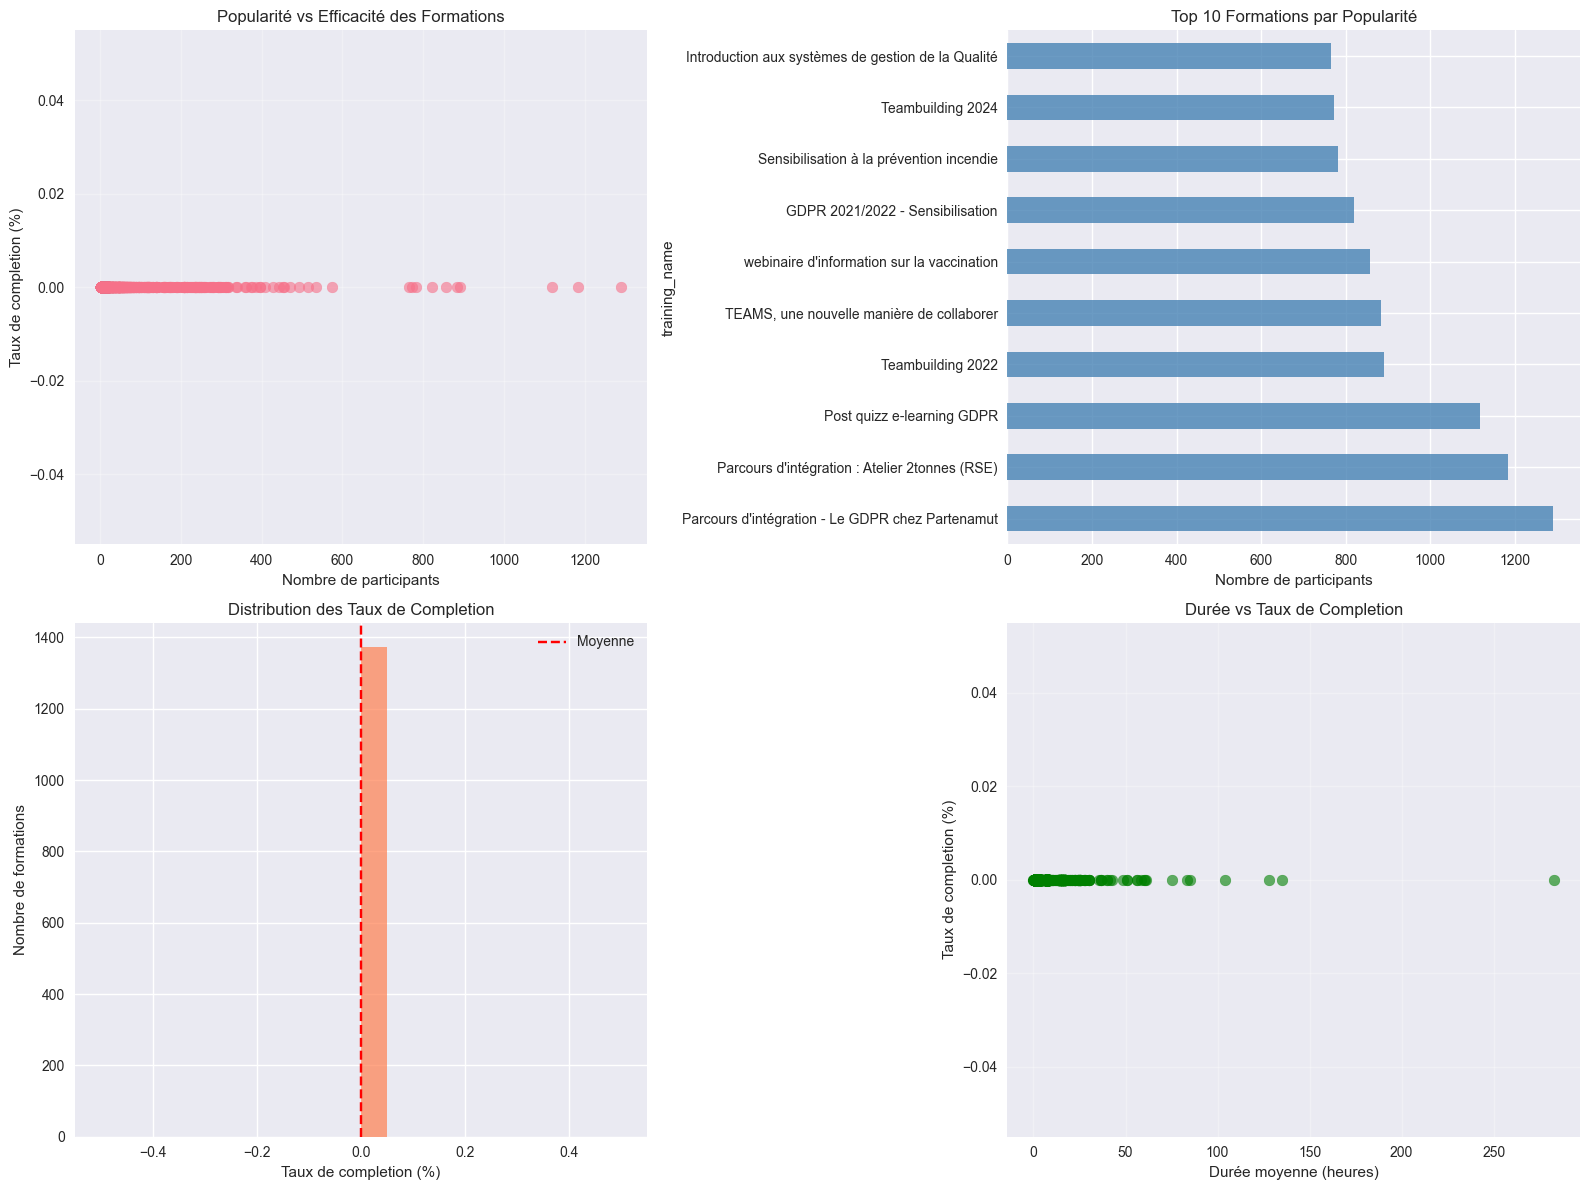

In [42]:
def analyze_popular_trainings(enriched_df):
    """
    Analyse les formations les plus populaires et leur efficacité
    """
    print("🎓 ANALYSE DES FORMATIONS POPULAIRES")
    print("=" * 50)
    
    # Statistiques par formation
    training_stats = enriched_df.groupby('training_name').agg({
        'dim_lxp_user_hk': 'nunique',
        'session_name': 'nunique',
        'duration_hours': ['sum', 'mean'],
        'status': lambda x: (x == 'completed').sum(),
        'traineepresence': lambda x: (x == 'present').sum(),
        'lmsprogresspercent': 'mean',
        'lmsaccesscount': 'sum'
    }).round(2)
    
    # Aplatissement des colonnes
    training_stats.columns = [
        'participants_uniques', 'sessions_total', 'duree_totale_h',
        'duree_moyenne_h', 'completions', 'presences',
        'progres_moyen_pct', 'acces_lms_total'
    ]
    
    # Calcul des taux
    training_stats['taux_completion'] = (
        training_stats['completions'] / training_stats['participants_uniques'] * 100
    ).round(1)
    
    training_stats['taux_presence'] = (
        training_stats['presences'] / training_stats['participants_uniques'] * 100
    ).round(1)
    
    # Top formations par popularité
    top_popular = training_stats.sort_values('participants_uniques', ascending=False).head(15)
    
    # Top formations par efficacité (taux de completion)
    top_effective = training_stats[
        training_stats['participants_uniques'] >= 10  # Minimum 10 participants
    ].sort_values('taux_completion', ascending=False).head(15)
    
    print("Top 10 formations les plus populaires :")
    print(top_popular[['participants_uniques', 'taux_completion', 'taux_presence']].head(10))
    
    print("\n Top 10 formations les plus efficaces (min. 10 participants) :")
    print(top_effective[['participants_uniques', 'taux_completion', 'taux_presence']].head(10))
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Popularité vs Efficacité
    axes[0,0].scatter(
        training_stats['participants_uniques'], 
        training_stats['taux_completion'],
        alpha=0.6, s=60
    )
    axes[0,0].set_xlabel('Nombre de participants')
    axes[0,0].set_ylabel('Taux de completion (%)')
    axes[0,0].set_title('Popularité vs Efficacité des Formations')
    axes[0,0].grid(True, alpha=0.3)
    
    # Top 10 formations populaires
    top_popular['participants_uniques'].head(10).plot(
        kind='barh', ax=axes[0,1], color='steelblue', alpha=0.8
    )
    axes[0,1].set_title('Top 10 Formations par Popularité')
    axes[0,1].set_xlabel('Nombre de participants')
    
    # Distribution des taux de completion
    axes[1,0].hist(training_stats['taux_completion'], bins=20, alpha=0.7, color='coral')
    axes[1,0].set_xlabel('Taux de completion (%)')
    axes[1,0].set_ylabel('Nombre de formations')
    axes[1,0].set_title('Distribution des Taux de Completion')
    axes[1,0].axvline(training_stats['taux_completion'].mean(), 
                      color='red', linestyle='--', label='Moyenne')
    axes[1,0].legend()
    
    # Durée vs Taux de completion
    axes[1,1].scatter(
        training_stats['duree_moyenne_h'], 
        training_stats['taux_completion'],
        alpha=0.6, s=60, color='green'
    )
    axes[1,1].set_xlabel('Durée moyenne (heures)')
    axes[1,1].set_ylabel('Taux de completion (%)')
    axes[1,1].set_title('Durée vs Taux de Completion')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return training_stats

training_analysis = analyze_popular_trainings(enriched_data)
